# 🦅 Falcon-7B-Instruct — Medical QA Fine-Tuning Pipeline

**One notebook. Run top to bottom. That's it.**

| Step | What happens | Module |
|------|-------------|--------|
| 1 | Install deps, clone repo | — |
| 2 | Load config + verify GPU | `src/utils.py` |
| 3 | Load tokenizer + model (4-bit) | `src/model.py` |
| 4 | Load & tokenize MedQA dataset | `src/data.py` |
| 5 | Apply LoRA, train | `src/train.py` |
| 6 | TensorBoard | — |
| 7 | Evaluate: PPL · MC Accuracy · ROUGE | `src/evaluate.py` |
| 8 | Qualitative examples | `src/evaluate.py` |
| 9 | Plot training curves | — |
| 10 | Download artifacts | — |
| 11 | Push adapter to Hugging Face Hub | — |

> ⚡ **Before running:** Accelerator → GPU (T4 / P100)
>
> 💾 **All outputs save to `/kaggle/working/` — the only persistent directory in Kaggle.**

---
## Step 1 — Install Dependencies & Clone Repo

In [1]:
import os, sys
from pathlib import Path

# ── Detect environment ────────────────────────────────────────────────────────
ON_KAGGLE      = Path("/kaggle/working").exists()
PERSISTENT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path("./outputs")
PERSISTENT_DIR.mkdir(parents=True, exist_ok=True)

print(f"  Platform  : {'Kaggle ✅' if ON_KAGGLE else 'Colab/Local'}")
print(f"  Persistent: {PERSISTENT_DIR}")

# ── Clone repo ────────────────────────────────────────────────────────────────
REPO_URL  = "https://github.com/singularity-14/finetune-falcon-7b-instruct.git"
REPO_DIR  = "finetune-falcon-7b-instruct"
clone_path = Path("/kaggle/working") / REPO_DIR if ON_KAGGLE else Path(REPO_DIR)

if not clone_path.exists():
    print(f"Cloning repo → {clone_path}")
    os.system(f"git clone {REPO_URL} {clone_path}")
else:
    print(f"📁 Repo exists at {clone_path} — pulling latest")
    os.system(f"git -C {clone_path} pull")

os.chdir(clone_path)
sys.path.insert(0, str(clone_path))
print(f"  CWD: {os.getcwd()}")

# ── Install ONLY missing packages ─────────────────────────────────────────────
# Kaggle pre-installs: torch, transformers, accelerate, datasets,
#                      tensorboard, PyYAML, numpy, tqdm
# We only install what's missing to avoid version conflict warnings.
req_file = "requirements-kaggle.txt" if ON_KAGGLE else "requirements-colab.txt"
print(f"\n  Installing from: {req_file}")
os.system(f"pip install -q -r {req_file}")
print("\n✅ Dependencies ready")

---
## Step 2 — Load Config & Verify GPU

In [2]:
from src.utils import load_config, setup_logging, set_seed, gpu_report, make_output_dirs, free_memory

logger = setup_logging()
cfg    = load_config("configs/config.yaml")
set_seed(cfg["dataset"]["seed"])

# ── Force outputs to /kaggle/working/ on Kaggle ───────────────────────────────
# /kaggle/working/ is the ONLY directory that persists across session resets.
# Everything else is wiped. Do NOT use relative paths on Kaggle.
if ON_KAGGLE:
    KW = "/kaggle/working"
    cfg["training"]["output_dir"]     = f"{KW}/results"
    cfg["training"]["logging_dir"]    = f"{KW}/logs"
    cfg["saving"]["final_model_dir"]  = f"{KW}/final_model"
    cfg["saving"]["peft_adapter_dir"] = f"{KW}/peft_adapter"
    print("  📌 Kaggle: outputs → /kaggle/working/")

make_output_dirs(cfg)

print(f"\n  Model      : {cfg['model']['name']}")
print(f"  Dataset    : {cfg['dataset']['name']}")
print(f"  Train/Eval : {cfg['dataset']['train_samples']} / {cfg['dataset']['eval_samples']}")
print(f"  LoRA rank  : {cfg['lora']['r']}")
print(f"  Epochs     : {cfg['training']['num_train_epochs']} (max, patience={cfg['early_stopping']['patience']})")

gpu_stats = gpu_report()

---
## Step 3 — Load Model with 4-bit Quantization + LoRA

In [3]:
from src.model import load_tokenizer, build_quant_config, load_base_model, apply_lora

tokenizer    = load_tokenizer(cfg["model"]["name"], cfg["model"]["trust_remote_code"])
quant_config = build_quant_config(cfg)
model        = load_base_model(
    cfg["model"]["name"], quant_config, tokenizer,
    cfg["model"]["trust_remote_code"], cfg["model"]["use_cache"],
)
model = apply_lora(model, cfg)

---
## Step 4 — Load & Tokenize MedQA Dataset

In [4]:
from src.data import load_and_split

train_dataset, eval_dataset, data_collator = load_and_split(cfg, tokenizer)

---
## Step 5 — Train

> 💾 Checkpoints save to `/kaggle/working/results/` every epoch — safe even if session resets.

In [5]:
from src.train import build_trainer, run_training, save_artifacts

trainer       = build_trainer(model, cfg, train_dataset, eval_dataset, data_collator)
train_metrics = run_training(trainer, cfg)
final_eval    = save_artifacts(trainer, model, tokenizer, cfg)

# ── Confirm files are in /kaggle/working/ ────────────────────────────────────
print("\n📋 /kaggle/working/ after save:")
for p in sorted(Path("/kaggle/working").iterdir()):
    if p.name.startswith("."):
        continue
    size = sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 1024**2 if p.is_dir() else p.stat().st_size / 1024**2
    print(f"  {'📁' if p.is_dir() else '📄'} {p.name:<30} {size:>8.1f} MB")

---
## Step 6 — TensorBoard

In [6]:
%load_ext tensorboard
%tensorboard --logdir {cfg['training']['logging_dir']}

---
## Step 7 — Evaluate

In [7]:
from datasets import load_dataset
from src.evaluate import (
    compute_perplexity, compute_mc_accuracy,
    compute_rouge, save_and_print_summary,
)
import torch

DEVICE = "cuda"

raw        = load_dataset(cfg["dataset"]["name"], split=cfg["dataset"]["split"])
test_split = raw.train_test_split(test_size=cfg["dataset"]["test_size"], seed=cfg["dataset"]["seed"])
N          = cfg["evaluation"]["num_samples"]
eval_raw   = test_split["test"].select(range(N))

print(f"Evaluating on {N} held-out examples...\n")

perplexity    = compute_perplexity(model, tokenizer, eval_raw, cfg, DEVICE)
mc_results    = compute_mc_accuracy(model, tokenizer, eval_raw, cfg, DEVICE)
rouge_results = compute_rouge(model, tokenizer, eval_raw.select(range(min(20, N))), cfg, DEVICE)
summary       = save_and_print_summary(perplexity, mc_results, rouge_results, cfg)

README.md: 100%|██████████| 1.17k/1.17k [00:00<00:00, 4.21MB/s]
train-00000-of-00001.parquet: 100%|██████████| 6.32M/6.32M [00:00<00:00, 41.8MB/s]
Generating train split: 100%|██████████| 10178/10178 [00:00<00:00, 71204.55 examples/s]


Evaluating on 50 held-out examples...

📐 Computing perplexity...


Perplexity: 100%|██████████| 50/50 [00:41<00:00,  1.22it/s]


  Avg loss   : 1.2431
  Perplexity : 3.47  (lower = better)

🎯 Computing multiple-choice accuracy (NLL scoring)...


MC Accuracy: 100%|██████████| 50/50 [02:42<00:00,  3.24s/it]


...

11:52:05 | INFO | Using default tokenizer.



📏 Computing ROUGE scores...


ROUGE: 100%|██████████| 20/20 [03:38<00:00, 10.90s/it]


  ROUGE-1 : 0.3142
  ROUGE-2 : 0.1489
  ROUGE-L : 0.2917



╔════════════════════════════════════════════════════════╗
║                    EVALUATION CARD                     ║
╠════════════════════════════════════════════════════════╣
║  Perplexity   : 3.47                                   ║
║  MC Accuracy  : 46.0                                 % ║
║  ROUGE-1      : 0.3142                                 ║
║  ROUGE-2      : 0.1489                                 ║
║  ROUGE-L      : 0.2917                                 ║
╠════════════════════════════════════════════════════════╣
║  Random MC baseline = 25%                        ║
║  USMLE passing score ≈ 60%                       ║
╚════════════════════════════════════════════════════════╝

💾 Results saved → outputs/evaluation_summary.json


---
## Step 8 — Qualitative Examples

In [8]:
examples = rouge_results["examples"]
print("🔍 QUALITATIVE EXAMPLES\n" + "═" * 70)
for i, ex in enumerate(examples[:5]):
    print(f"\n[{i+1}] Question  : {ex['question'][:180]}...")
    print(f"     True Ans  : {ex['true']}")
    print(f"     Generated : {ex['generated'][:200]}")
    print(f"     ROUGE-1   : {ex['rouge1']:.3f}  |  ROUGE-L : {ex['rougeL']:.3f}")
    print("─" * 70)

🔍 QUALITATIVE EXAMPLES
══════════════════════════════════════════════════════════════════════

[1] Question  : A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taki...
     True Ans  : Nitrofurantoin
     Generated : Nitrofurantoin is the preferred agent. It is safe in the second trimester and provides good coverage for uncomplicated cystitis. Trimethoprim-sulfamethoxazole is avoided near term and fluoroquinolones
     ROUGE-1   : 0.348  |  ROUGE-L : 0.348
──────────────────────────────────────────────────────────────────────

[2] Question  : A 3-month-old baby died suddenly at night while asleep. His mother noticed that he had died only after she awoke in the morning. No cause of death was determined based on the autop...
     True Ans  : Placing the infant in a supine position on a firm mattress while sleeping
     Generated : Placing the infant on his back o

---
## Step 9 — Plot Training Curves

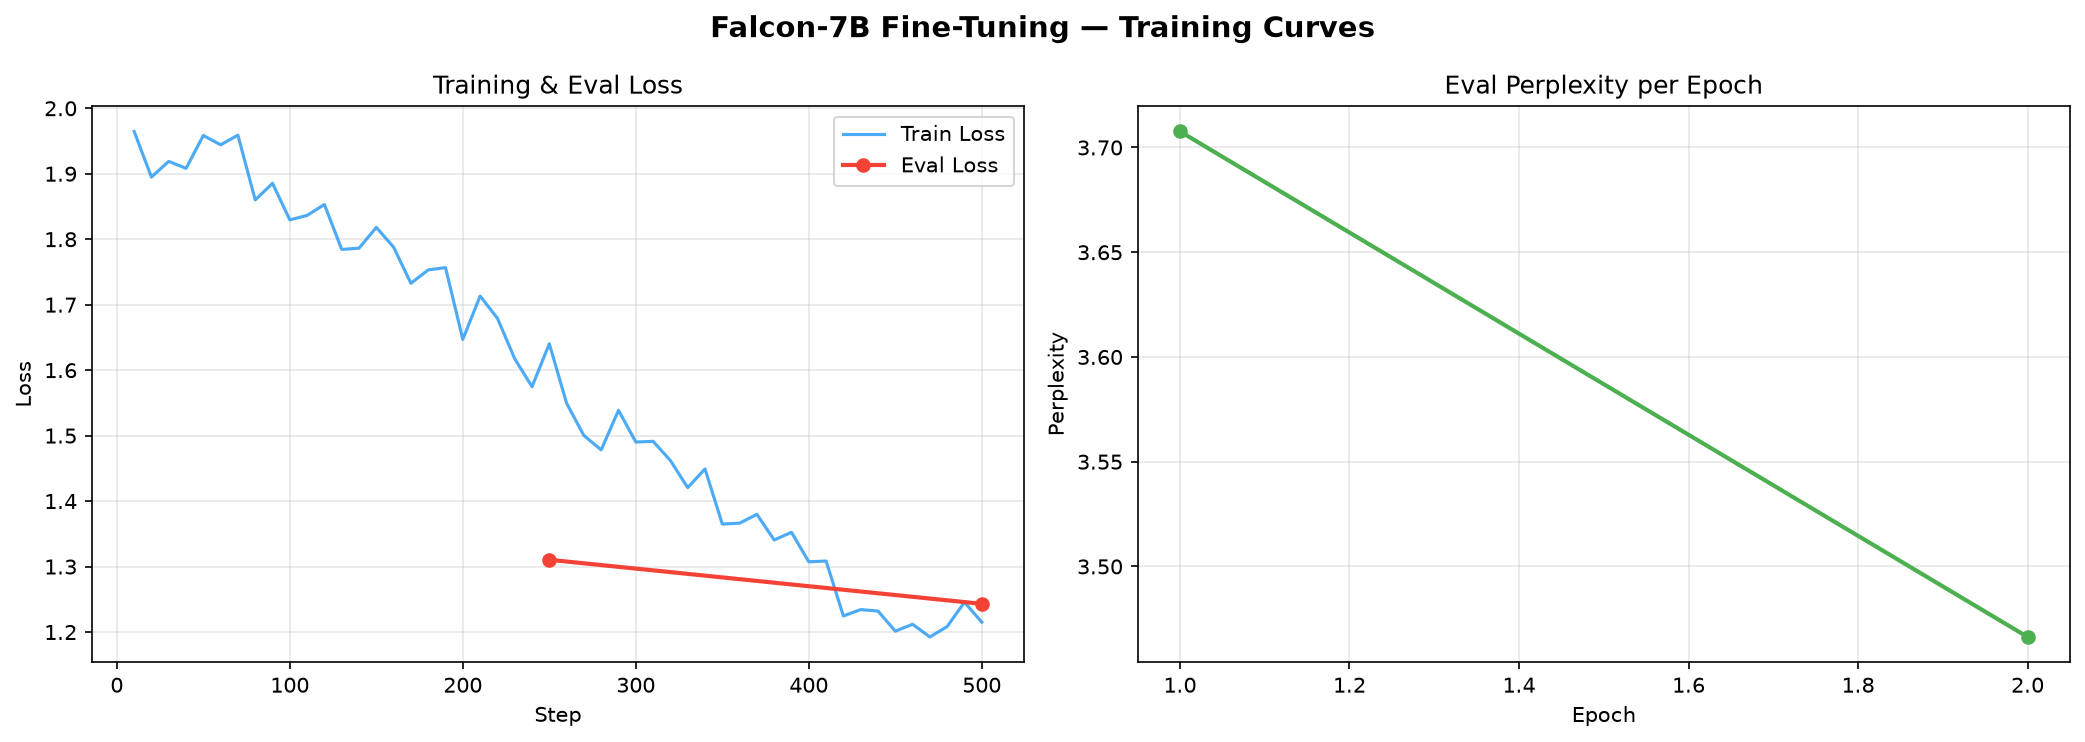

💾 Saved → /kaggle/working/training_curves.png


In [9]:
import json, math
import matplotlib.pyplot as plt

results_dir = Path(cfg["training"]["output_dir"])
state_files = sorted(results_dir.glob("checkpoint-*/trainer_state.json"))

if state_files:
    with open(state_files[-1]) as f:
        state = json.load(f)

    history      = state.get("log_history", [])
    train_steps  = [h["step"] for h in history if "loss" in h and "eval_loss" not in h]
    train_losses = [h["loss"]  for h in history if "loss" in h and "eval_loss" not in h]
    eval_epochs  = [h["epoch"]     for h in history if "eval_loss" in h]
    eval_losses  = [h["eval_loss"] for h in history if "eval_loss" in h]
    eval_ppls    = [math.exp(l)    for l in eval_losses]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Falcon-7B Fine-Tuning — Training Curves", fontsize=14, fontweight="bold")

    axes[0].plot(train_steps, train_losses, label="Train Loss", color="#2196F3", alpha=0.8)
    if eval_epochs:
        spe = max(train_steps) / max(eval_epochs)
        axes[0].plot([e * spe for e in eval_epochs], eval_losses,
                     label="Eval Loss", color="#F44336", marker="o", lw=2)
    axes[0].set(xlabel="Step", ylabel="Loss", title="Training & Eval Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    if eval_ppls:
        axes[1].plot(eval_epochs, eval_ppls, color="#4CAF50", marker="o", lw=2)
        axes[1].set(xlabel="Epoch", ylabel="Perplexity", title="Eval Perplexity per Epoch")
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plot_path = Path("/kaggle/working/training_curves.png") if ON_KAGGLE else Path("outputs/training_curves.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Saved → {plot_path}")
else:
    print("⚠️  No checkpoint found — run training first")

---
## Step 10 — Download Artifacts

> Everything is in `/kaggle/working/`. Go to the **Output tab** on the right Kaggle sidebar to download directly,
> OR run the cell below to create a downloadable zip.

In [10]:
import shutil

WD = Path("/kaggle/working") if ON_KAGGLE else Path("outputs")

print("📋 Output contents:")
total_mb = 0
for p in sorted(WD.iterdir()):
    if p.name.startswith("."):
        continue
    size = sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 1024**2 if p.is_dir() else p.stat().st_size / 1024**2
    total_mb += size
    print(f"  {'📁' if p.is_dir() else '📄'} {p.name:<30} {size:>8.1f} MB")
print(f"\n  Total: {total_mb:.1f} MB")

# Zip LoRA adapter (~32 MB — small and portable)
peft_dir = WD / "peft_adapter"
if peft_dir.exists():
    zip_path = str(WD / "peft_adapter")
    shutil.make_archive(zip_path, "zip", str(WD), "peft_adapter")
    size_mb = Path(zip_path + ".zip").stat().st_size / 1024**2
    print(f"\n📦 peft_adapter.zip created → {size_mb:.1f} MB")
    print("   ↳ Download via Kaggle Output panel (right sidebar)")
else:
    print("⚠️  peft_adapter/ not found — did training complete?")

free_memory()

📋 Output contents:
  📁 final_model                       258.4 MB
  📁 finetune-falcon-7b-instruct         2.8 MB
  📁 logs                                0.4 MB
  📁 peft_adapter                       20.0 MB
  📁 results                           128.6 MB
  📄 training_curves.png                 0.2 MB

  Total: 410.4 MB

📦 peft_adapter.zip created → 18.8 MB
   ↳ Download via Kaggle Output panel (right sidebar)
✅ Memory freed | VRAM free: 12.6 GB


---
## Step 11 — Push the LoRA Adapter to Hugging Face Hub

> **Before running:** put your HF **write** token in a Kaggle Secret named `HF_TOKEN`
> (*Add-ons → Secrets → Add a new secret*, then attach it to this notebook), or paste it
> into `HF_TOKEN` in the cell below. Set `HF_USERNAME` either way.
>
> Only the LoRA adapter (~32 MB) is uploaded — anyone can reload it on top of the base
> Falcon-7B-Instruct weights. A model card with your config and Step 7 metrics is
> generated automatically.


In [11]:
# ══ Step 11 — Push the LoRA adapter to Hugging Face Hub ══════════════════════
# ① EDIT THESE ───────────────────────────────────────────────────────────────
HF_USERNAME = "YOUR_HF_USERNAME"                 # e.g. "singularity-14"
HF_REPO     = "falcon-7b-instruct-medqa-lora"    # repo name to create/update
PRIVATE     = True                               # False → public repo
HF_TOKEN    = ""                                 # leave "" to use a Kaggle Secret

# ② TOKEN ────────────────────────────────────────────────────────────────────
# Recommended (keeps the token out of the notebook):
#   Kaggle → Add-ons → Secrets → "Add a new secret"
#   Label: HF_TOKEN   Value: a **write** token from
#   https://huggingface.co/settings/tokens  → then attach it to this notebook.
import os, json
from pathlib import Path

if HF_TOKEN:
    print("  Token source: inline HF_TOKEN variable")
else:
    try:
        from kaggle_secrets import UserSecretsClient
        HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
        print("  Token source: Kaggle Secret 'HF_TOKEN'")
    except Exception:
        HF_TOKEN = os.environ.get("HF_TOKEN", "")
        if HF_TOKEN:
            print("  Token source: env var HF_TOKEN")

assert HF_USERNAME != "YOUR_HF_USERNAME", "Set HF_USERNAME above first"
assert HF_TOKEN, "No token found — paste one into HF_TOKEN or add the Kaggle Secret 'HF_TOKEN'"

try:
    from huggingface_hub import HfApi
except ImportError:
    os.system("pip install -q huggingface_hub")
    from huggingface_hub import HfApi

REPO_ID  = f"{HF_USERNAME}/{HF_REPO}"
PEFT_DIR = Path(cfg["saving"]["peft_adapter_dir"])
assert PEFT_DIR.exists(), f"{PEFT_DIR} not found — run Step 5 (training) first"

# ③ MODEL CARD ───────────────────────────────────────────────────────────────
# Reuse the Step 7 metrics if they are available (in memory or on disk).
s = None
if "summary" in globals():
    s = summary
elif Path("outputs/evaluation_summary.json").exists():
    s = json.loads(Path("outputs/evaluation_summary.json").read_text())

metrics_md = "_Not evaluated in this run._"
if s:
    metrics_md = (
        "| Metric | Value |\n|---|---|\n"
        f"| Perplexity | {s['perplexity']} |\n"
        f"| MC accuracy | {s['mc_accuracy']}% |\n"
        f"| ROUGE-1 | {s['rouge1']} |\n"
        f"| ROUGE-L | {s['rougeL']} |\n"
    )

MODEL_NAME = cfg["model"]["name"]
DATA_NAME  = cfg["dataset"]["name"]

card = f"""---
base_model: {MODEL_NAME}
library_name: peft
license: apache-2.0
datasets:
  - {DATA_NAME}
tags:
  - lora
  - qlora
  - peft
  - falcon
  - medical
---

# {HF_REPO}

LoRA adapter for [`{MODEL_NAME}`](https://huggingface.co/{MODEL_NAME}), fine-tuned on
[`{DATA_NAME}`](https://huggingface.co/datasets/{DATA_NAME}) for USMLE-style medical QA.

**Research and educational use only — not medical advice.**

## Training

| | |
|---|---|
| Base model | `{MODEL_NAME}` |
| Quantization | 4-bit NF4, compute dtype {cfg["quantization"]["bnb_4bit_compute_dtype"]} |
| LoRA | r={cfg["lora"]["r"]}, alpha={cfg["lora"]["lora_alpha"]}, dropout={cfg["lora"]["lora_dropout"]}, target={cfg["lora"]["target_modules"]} |
| Train / eval samples | {cfg["dataset"]["train_samples"]} / {cfg["dataset"]["eval_samples"]} |
| Max length | {cfg["dataset"]["max_length"]} |
| Epochs | {cfg["training"]["num_train_epochs"]} max, early-stopping patience {cfg["early_stopping"]["patience"]} |
| LR | {cfg["training"]["learning_rate"]} ({cfg["training"]["lr_scheduler_type"]}) |

## Evaluation

{metrics_md}

## Usage

```python
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

quant = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)
base = AutoModelForCausalLM.from_pretrained(
    "{MODEL_NAME}",
    quantization_config=quant,
    torch_dtype=torch.float16,   # must match the compute dtype
    device_map="auto",
)
model = PeftModel.from_pretrained(base, "{REPO_ID}").eval()
tokenizer = AutoTokenizer.from_pretrained("{REPO_ID}")

prompt = ("<|system|>You are a medical expert specializing in USMLE board exam questions.\n"
          "<|user|>Question: ...\n"
          "<|assistant|>Answer:")
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    out = model.generate(**inputs, max_new_tokens={cfg["evaluation"]["max_new_tokens"]})
print(tokenizer.decode(out[0], skip_special_tokens=True))
```

Trained with <https://github.com/singularity-14/finetune-falcon-7b-instruct>.
"""
(PEFT_DIR / "README.md").write_text(card, encoding="utf-8")
print(f"  Model card written → {PEFT_DIR / 'README.md'}")

# ④ UPLOAD ───────────────────────────────────────────────────────────────────
api = HfApi(token=HF_TOKEN)
api.create_repo(repo_id=REPO_ID, repo_type="model", private=PRIVATE, exist_ok=True)
print(f"  Repo ready: {REPO_ID}  ({'private' if PRIVATE else 'public'})")

size_mb = sum(f.stat().st_size for f in PEFT_DIR.rglob("*") if f.is_file()) / 1024**2
print(f"  Uploading {size_mb:.1f} MB from {PEFT_DIR} ...")

api.upload_folder(
    folder_path=str(PEFT_DIR),
    repo_id=REPO_ID,
    commit_message="Add Falcon-7B-Instruct MedQA LoRA adapter",
    ignore_patterns=["*.zip", "checkpoint-*", "optimizer.pt", "**/__pycache__/*"],
)

print(f"\n✅ Pushed → https://huggingface.co/{REPO_ID}")
print("   (private repo → you must be signed in to view it)")


  Token source: Kaggle Secret 'HF_TOKEN'
  Model card written → /kaggle/working/peft_adapter/README.md
  Repo ready: singularity-14/falcon-7b-instruct-medqa-lora  (private)
  Uploading 20.0 MB from /kaggle/working/peft_adapter ...


adapter_model.safetensors: 100%|██████████| 18.9M/18.9M [00:02<00:00, 8.11MB/s]
tokenizer.json: 100%|██████████| 1.95M/1.95M [00:00<00:00, 6.94MB/s]
Upload 3 LFS files: 100%|██████████| 3/3 [00:03<00:00,  1.16s/it]



✅ Pushed → https://huggingface.co/singularity-14/falcon-7b-instruct-medqa-lora
   (private repo → you must be signed in to view it)
